In [3]:
# Import packages
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
import matplotlib.patches as patches
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import shapiro, levene
from scipy.stats import anderson, normaltest

In [4]:
# --- INPUT USER  ---
input_dir = '/Users/laureleblanc/Desktop/Collective-twitching-2026/6_maze_exploration/probability_of_escape/dataset'  
output_dir = '/Users/laureleblanc/Desktop/Collective-twitching-2026/6_maze_exploration/probability_of_escape/figures'
#--------------------
os.makedirs(output_dir, exist_ok=True)


✅ Found 6 image pairs.


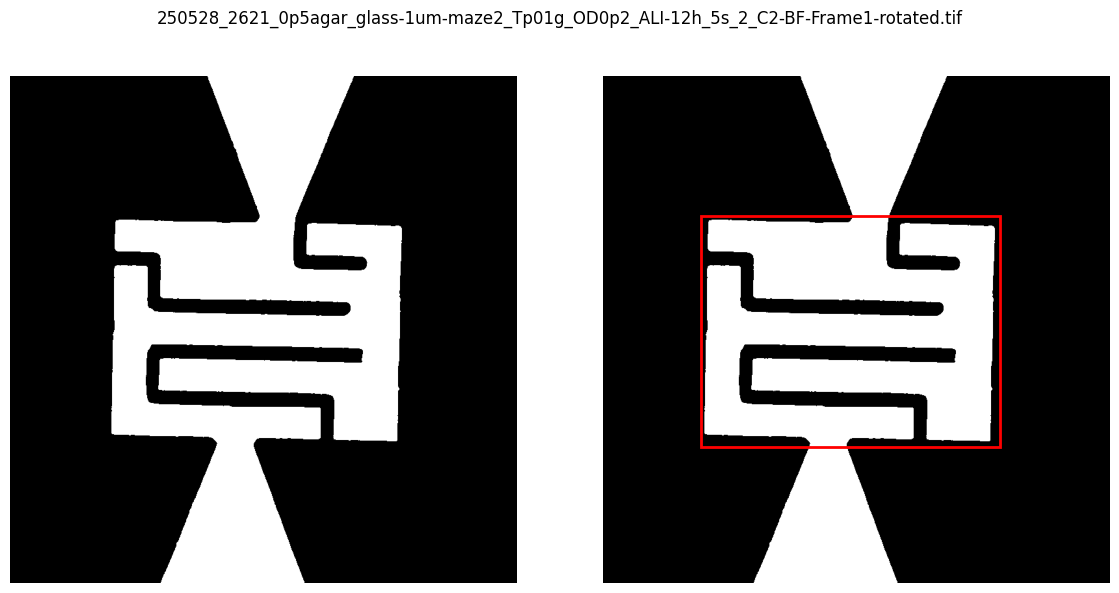

File: 250528_2621_0p5agar_glass-1um-maze2_Tp01g_OD0p2_ALI-12h_5s_2_C2-BF-Frame1-rotated.tif | Total: 42, Inside: 42, Outside: 0, Prob escape: 0.00%


/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_65300/1368611418.py:199: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


No perfect rectangle found, returning best with white fraction 0.74


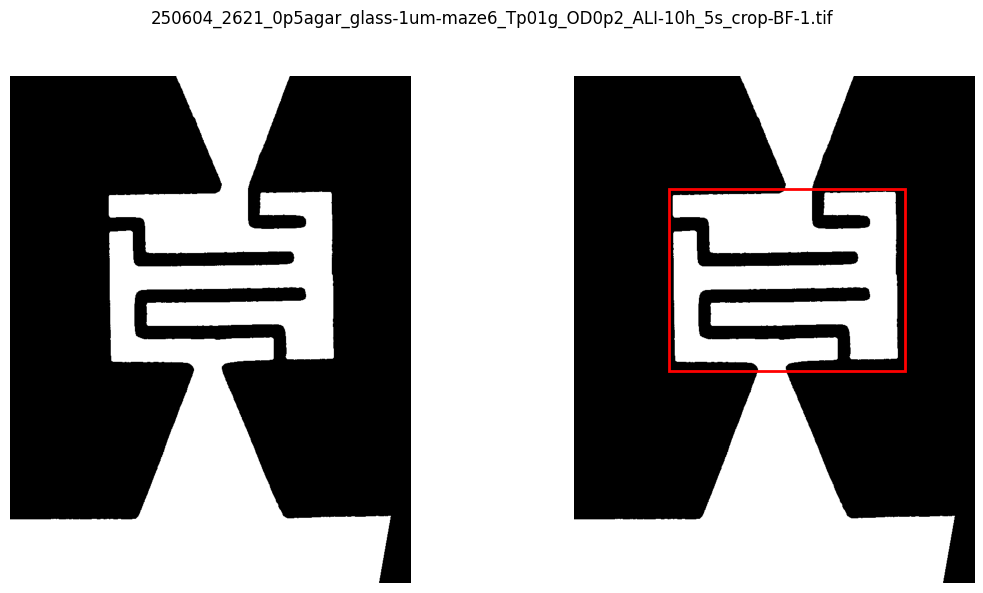

File: 250604_2621_0p5agar_glass-1um-maze6_Tp01g_OD0p2_ALI-10h_5s_crop-BF-1.tif | Total: 24, Inside: 24, Outside: 0, Prob escape: 0.00%


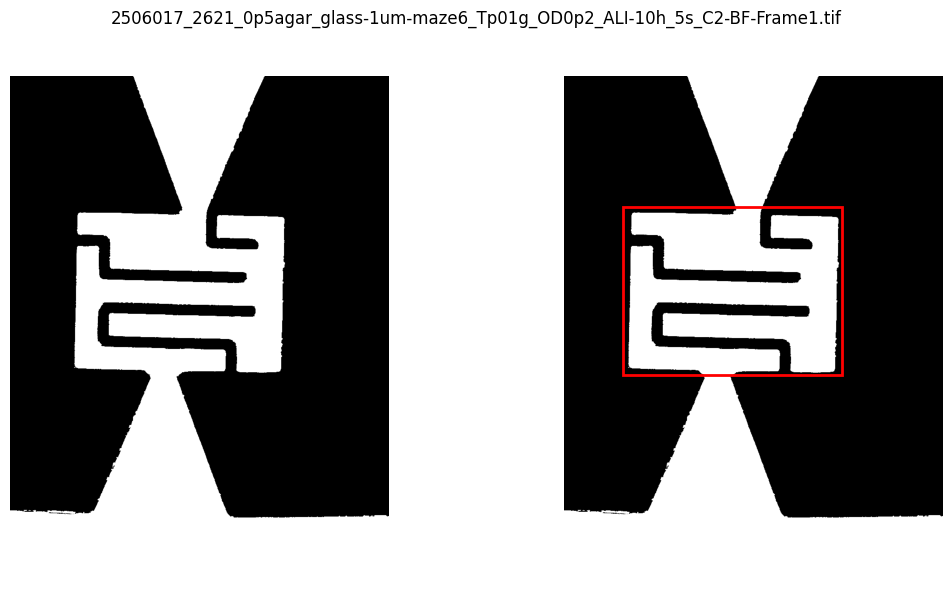

File: 2506017_2621_0p5agar_glass-1um-maze6_Tp01g_OD0p2_ALI-10h_5s_C2-BF-Frame1.tif | Total: 59, Inside: 58, Outside: 1, Prob escape: 1.69%


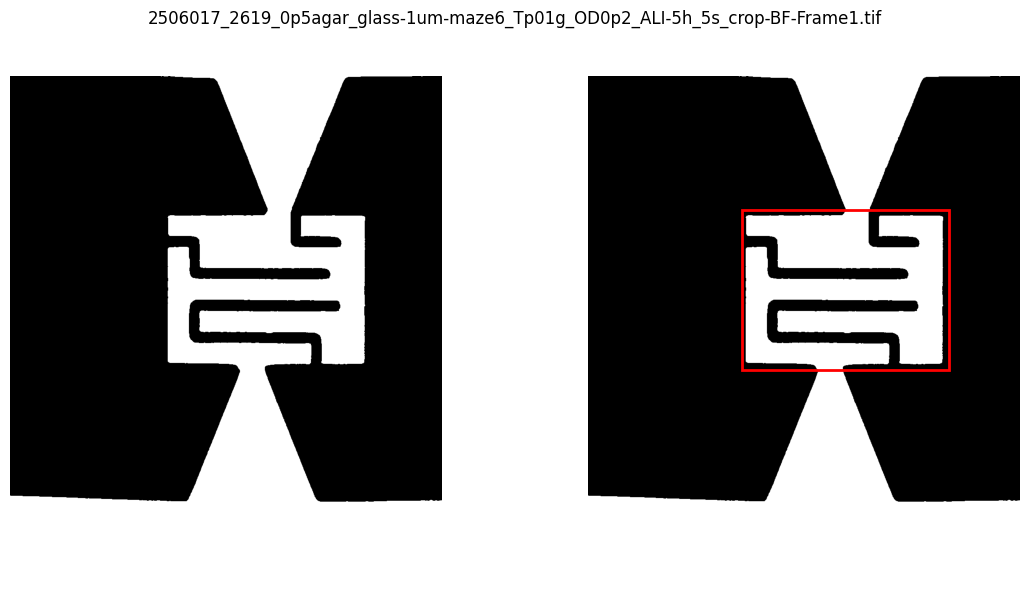

File: 2506017_2619_0p5agar_glass-1um-maze6_Tp01g_OD0p2_ALI-5h_5s_crop-BF-Frame1.tif | Total: 77, Inside: 57, Outside: 20, Prob escape: 25.97%


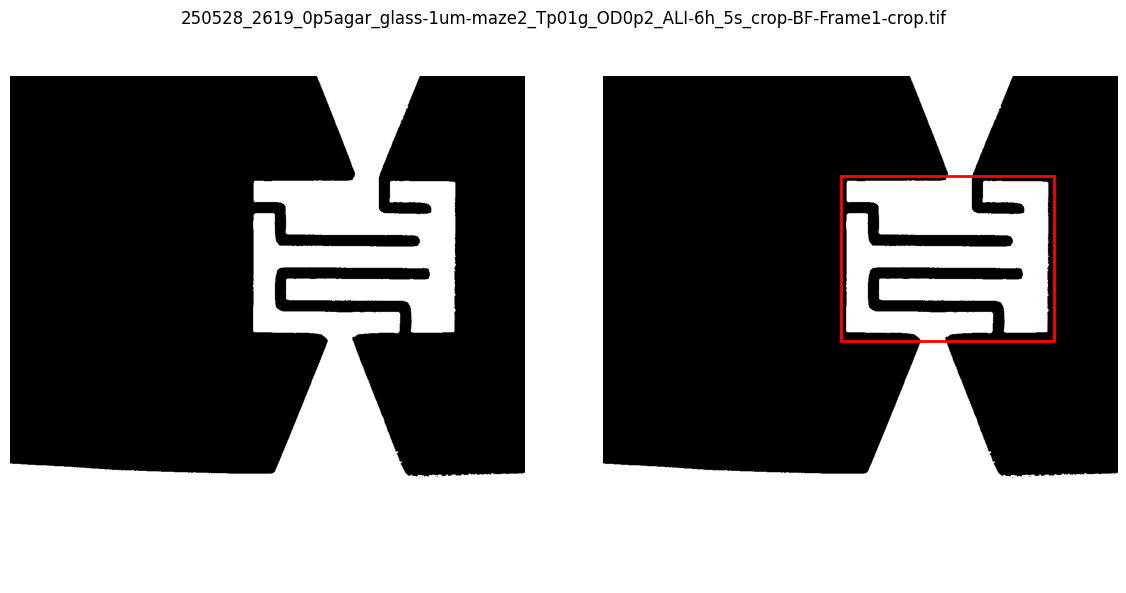

File: 250528_2619_0p5agar_glass-1um-maze2_Tp01g_OD0p2_ALI-6h_5s_crop-BF-Frame1-crop.tif | Total: 18, Inside: 13, Outside: 5, Prob escape: 27.78%


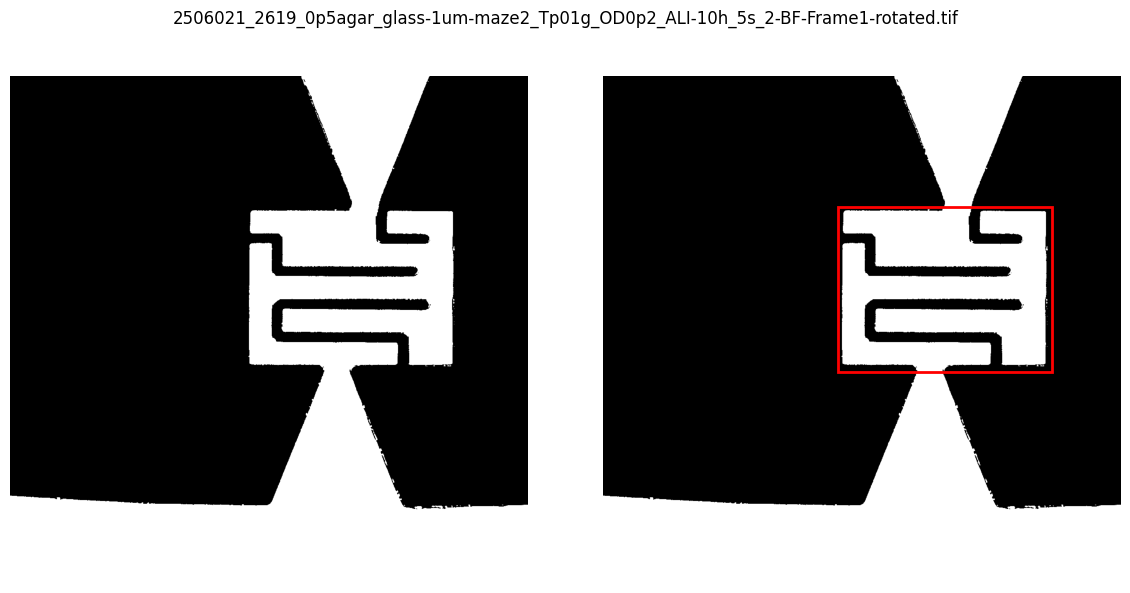

File: 2506021_2619_0p5agar_glass-1um-maze2_Tp01g_OD0p2_ALI-10h_5s_2-BF-Frame1-rotated.tif | Total: 145, Inside: 128, Outside: 17, Prob escape: 11.72%

✅ Results saved to /Users/laureleblanc/Desktop/Collective-twitching-2026/6_maze_exploration/probability_of_escape/figures/escape_probability_results.csv


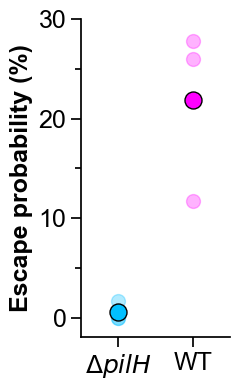

In [5]:
# Size of the window
RECT_WIDTH = 440
RECT_HEIGHT = 335

# --- Helper functions ---

def get_root_key(filename):
    pos = filename.find('5s')
    if pos == -1:
        # If '5s' not found, fallback to whole filename or some other logic
        return filename  
    else:
        # Include '5s' (pos+2) to keep the pattern fully
        return filename[:pos+2]



def get_strain(filename):
    if '2619' in filename:
        return 'WT'
    elif '2621' in filename:
        return 'mutant'
    else:
        return 'unknown'

def find_rect_in_maze(mask, width, height, min_white_fraction=0.75):
    coords = np.column_stack(np.where(mask))
    if len(coords) == 0:
        print("Mask is empty! No white pixels found.")
        return None

    minr, minc = coords.min(axis=0)
    maxr, maxc = coords.max(axis=0)
    
    h_roi = maxr - minr + 1
    w_roi = maxc - minc + 1
    
    if h_roi < height or w_roi < width:
        print("Maze bounding box too small for rectangle")
        return None
    
    roi = mask[minr:maxr+1, minc:maxc+1]
    
    max_fraction = 0
    best_pos = None
    
    for r_start in range(0, h_roi - height + 1, 5):
        for c_start in range(0, w_roi - width + 1, 5):
            window = roi[r_start:r_start+height, c_start:c_start+width]
            white_fraction = np.mean(window)
            if white_fraction >= min_white_fraction:
                return (minc + c_start, minr + r_start, width, height)
            if white_fraction > max_fraction:
                max_fraction = white_fraction
                best_pos = (minc + c_start, minr + r_start, width, height)
    
    if best_pos:
        print(f"No perfect rectangle found, returning best with white fraction {max_fraction:.2f}")
    else:
        print("No suitable rectangle found")
    return best_pos



def count_bacteria_in_rect(seg_img, rect):
    x, y, w, h = rect
    roi = seg_img[y:y+h, x:x+w]
    labels = np.unique(roi)
    return len(labels[labels != 0])

def count_bacteria_outside_rect(seg_img, rect):
    x, y, w, h = rect
    h_img, w_img = seg_img.shape
    roi = seg_img[y+h:h_img, 0:w_img]
    labels = np.unique(roi)
    return len(labels[labels != 0])

def plot_mask_and_mask_with_rectangle(mask, rect, filename):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(mask, cmap='gray')
    axs[0].axis('off')

    axs[1].imshow(mask, cmap='gray')
    if rect is not None:
        x, y, w, h = rect
        rect_patch = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        axs[1].add_patch(rect_patch)
    axs[1].axis('off')

    fig.suptitle(filename)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
    plt.savefig(output_dir + '/' + filename [:-3] + '_mask-detection.png', dpi=300, bbox_inches='tight', transparent = True)
    plt.show()

# --- Load files and find pairs ---

files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.tif', '.tiff', '.png', '.jpg'))]

bf_files = [f for f in files if 'bf' in f.lower()]
seg_files = [f for f in files if 'segmented' in f.lower()]

bf_dict = {get_root_key(f): f for f in bf_files}
seg_dict = {get_root_key(f): f for f in seg_files}

paired_files = []
for key in bf_dict:
    if key in seg_dict:
        paired_files.append((
            os.path.join(input_dir, bf_dict[key]),
            os.path.join(input_dir, seg_dict[key])
        ))
    else:
        print(f"❌ No segmented match for BF: {bf_dict[key]} (key = {key})")

print(f"\n✅ Found {len(paired_files)} image pairs.")

# --- Create empty DataFrame to store results ---

columns = ['filename', 'strain', 'number_bacteria_total', 'number_bacteria_inside', 'number_bacteria_outside', 'probability of escape']
df = pd.DataFrame(columns=columns)

# --- Process each pair ---

for bf_path, seg_path in paired_files:
    filename = os.path.basename(bf_path)
    strain = get_strain(filename)
    
    bf_img = cv2.imread(bf_path, cv2.IMREAD_GRAYSCALE)
    if bf_img is None:
        print(f"⚠️ Could not load {bf_path}")
        continue
    
    thresh_val = threshold_otsu(bf_img)
    mask = bf_img > thresh_val

    rect = find_rect_in_maze(mask, RECT_WIDTH, RECT_HEIGHT)

    if rect is not None:
        x, y, w, h = rect

        new_x = max(x - 5, 0)
        new_y = max(y - 5, 0)
        new_w = w + 20
        new_h = h + 20

        # Expand rectangle by 5 pixels on each side, but clamp to image size
        if filename == '2506021_2619_0p5agar_glass-1um-maze2_Tp01g_OD0p2_ALI-10h_5s_2-BF-Frame1-rotated.tif':
            new_x = max(x - 5, 0)
            new_y = max(y + 10, 0)
            new_w = w + 20 
            new_h = h + 20
            
        if filename == '250528_2621_0p5agar_glass-1um-maze2_Tp01g_OD0p2_ALI-12h_5s_2_C2-BF-Frame1-rotated.tif':
            new_x = max(x - 5, 0)
            new_y = max(y + 10, 0) 
            new_w = w + 20
            new_h = h + 20
    
        # Clamp new_w and new_h to image size
        max_w = bf_img.shape[1] - new_x
        max_h = bf_img.shape[0] - new_y

        new_w = min(new_w, max_w)
        new_h = min(new_h, max_h)

        rect = (new_x, new_y, new_w, new_h)
 
    if rect is None:
        print(f"⚠️ No fitting rectangle found in {filename}")
        plot_mask_and_mask_with_rectangle(mask, None, filename)
        continue

    plot_mask_and_mask_with_rectangle(mask, rect, filename)

    seg_img = cv2.imread(seg_path, cv2.IMREAD_UNCHANGED)
    if seg_img is None:
        print(f"⚠️ Could not load {seg_path}")
        continue
    
    n_inside = count_bacteria_in_rect(seg_img, rect)
    n_outside = count_bacteria_outside_rect(seg_img, rect)
    if filename == '2506017_2621_0p5agar_glass-1um-maze6_Tp01g_OD0p2_ALI-10h_5s_C2-BF-Frame1.tif':
        n_outside = n_outside - 2
    n_total = n_inside + n_outside
    prob_escape = 100 * n_outside / n_total if n_total > 0 else 0

    print(f"File: {filename} | Total: {n_total}, Inside: {n_inside}, Outside: {n_outside}, Prob escape: {prob_escape:.2f}%")
    
    new_row = {
        'filename': filename,
        'strain': strain,
        'number_bacteria_total': n_total,
        'number_bacteria_inside': n_inside,
        'number_bacteria_outside': n_outside,
        'probability of escape': prob_escape
    }
    
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# --- Save CSV once all files processed ---

csv_path = os.path.join(output_dir, 'escape_probability_results.csv')
df.to_csv(csv_path, index=False)
print(f"\n✅ Results saved to {csv_path}")

# --- FIRST Plot: Plot probability of escape by strain ---

plt.figure(figsize=(2.5, 4))

strains_order = [r'$\Delta\mathit{pilH}$', 'WT']
colors = {'WT': 'magenta', r'$\Delta\mathit{pilH}$': 'deepskyblue'}
strain_map = {'WT': 'WT', 'mutant': r'$\Delta\mathit{pilH}$'}  # maps internal label to display label

for raw_strain in ['WT', 'mutant']:
    display_strain = strain_map[raw_strain]
    y_vals = df[df['strain'] == raw_strain]['probability of escape'].values
    x_vals = np.full(len(y_vals), strains_order.index(display_strain))

    # Plot individual points (no label in legend)
    plt.scatter(x_vals, y_vals, color=colors[display_strain], s=100, alpha=0.3, label=None)

    # Plot mean with legend label
    if len(y_vals) > 0:
        avg = np.mean(y_vals)
        plt.scatter(strains_order.index(display_strain), avg, color=colors[display_strain], s=150,
                    edgecolors='k', label=display_strain)


plt.ylabel('Escape probability (%)', fontsize=18, fontweight='bold', fontname='Arial')
plt.xticks(range(len(strains_order)), strains_order, fontsize=18, fontname='Arial')
plt.yticks(fontsize=18, fontname='Arial')
plt.gca().margins(x=0.5)
plt.ylim(-2, 30)
plt.gca().yaxis.set_major_locator(plt.FixedLocator([0, 10, 20, 30]))
plt.gca().yaxis.set_minor_locator(plt.FixedLocator([5, 15, 25]))
plt.gca().tick_params(axis='both', which='major', length=7, width=1.25, color='black')
plt.gca().tick_params(axis='both', which='minor', length=4, width=1.25, color='black')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.25)
plt.gca().spines['bottom'].set_linewidth(1.25)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'escape_probability.png'), transparent=True, dpi = 300)
plt.show()


WT average spreading: 92.41%
pilH average spreading: 65.92%


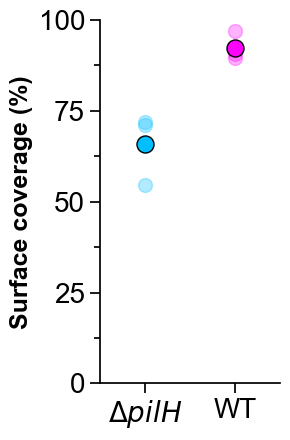

In [6]:
# Spreading quantification

# Step 1: Compute %Area in Fiji (see README file)

# Step 2:
# --- Save your data in a dictionary (data obtained from Fiji)  ---
data = {
    "WT": [89.524, 97.091, 90.609],
    "pilH": [72.037, 54.496, 71.235]
}

# Convert to DataFrame (long format for easier plotting)
records = []
for strain, values in data.items():
    for v in values:
        records.append({"strain": strain, "spreading": v})
df = pd.DataFrame(records)

# --- Print average spreading values ---
for strain, values in data.items():
    avg = np.mean(values)
    print(f"{strain} average spreading: {avg:.2f}%")

# --- Plot spreading quantification by strain ---
plt.figure(figsize=(3, 4.5))

# Display order and styles
strains_order = [r'$\Delta\mathit{pilH}$', 'WT']
colors = {'WT': 'magenta', r'$\Delta\mathit{pilH}$': 'deepskyblue'}
strain_map = {'WT': 'WT', 'pilH': r'$\Delta\mathit{pilH}$'}

for raw_strain in ['WT', 'pilH']:
    display_strain = strain_map[raw_strain]
    y_vals = df[df['strain'] == raw_strain]['spreading'].values
    x_vals = np.full(len(y_vals), strains_order.index(display_strain))

    # Plot individual points
    plt.scatter(x_vals, y_vals, color=colors[display_strain], s=100, alpha=0.3, label=None)

    # Plot mean
    if len(y_vals) > 0:
        avg = np.mean(y_vals)
        plt.scatter(strains_order.index(display_strain), avg, color=colors[display_strain],
                    s=150, edgecolors='k', label=display_strain)

plt.ylabel('Surface coverage (%)', fontsize=18, fontweight='bold', fontname='Arial')
plt.xticks(range(len(strains_order)), strains_order, fontsize=20, fontname='Arial')
plt.yticks(fontsize=20, fontname='Arial')
plt.gca().margins(x=0.5)
plt.ylim(0, 100)
plt.gca().yaxis.set_major_locator(plt.FixedLocator([0, 25, 50, 75, 100]))
plt.gca().yaxis.set_minor_locator(plt.FixedLocator([12.5, 37.5, 62.5, 87.5]))
plt.gca().tick_params(axis='both', which='major', length=7, width=1.25, color='black')
plt.gca().tick_params(axis='both', which='minor', length=4, width=1.25, color='black')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.25)
plt.gca().spines['bottom'].set_linewidth(1.25)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(output_dir, 'spreading_quantification.png'), transparent=True, dpi=300)
plt.show()
